In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from ISLP import load_data
from adjustText import adjust_text

In [7]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

In [10]:
Hitters = Hitters.dropna()
Hitters.shape

(263, 20)

In [11]:
Y = np.array(Hitters['Salary'])

X = pd.get_dummies(Hitters.drop('Salary',axis=1),drop_first = True).astype(float)

feature_names = X.columns
X = np.asarray(X)
X.shape

(263, 19)

In [13]:
Y

array([ 475.   ,  480.   ,  500.   ,   91.5  ,  750.   ,   70.   ,
        100.   ,   75.   , 1100.   ,  517.143,  512.5  ,  550.   ,
        700.   ,  240.   ,  775.   ,  175.   ,  135.   ,  100.   ,
        115.   ,  600.   ,  776.667,  765.   ,  708.333,  750.   ,
        625.   ,  900.   ,  110.   ,  612.5  ,  300.   ,  850.   ,
         90.   ,   67.5  ,  180.   ,  305.   ,  215.   ,  247.5  ,
        815.   ,  875.   ,   70.   , 1200.   ,  675.   ,  415.   ,
        340.   ,  416.667, 1350.   ,   90.   ,  275.   ,  230.   ,
        225.   ,  950.   ,   75.   ,  105.   ,  320.   ,  850.   ,
        535.   ,  933.333,  850.   ,  210.   ,  325.   ,  275.   ,
        450.   , 1975.   , 1900.   ,  600.   , 1041.667,  110.   ,
        260.   ,  475.   ,  431.5  , 1220.   ,   70.   ,  145.   ,
        595.   , 1861.46 ,  300.   ,  490.   , 2460.   ,  375.   ,
        750.   , 1175.   ,   70.   , 1500.   ,  385.   , 1925.571,
        215.   ,  900.   ,  155.   ,  700.   ,  535.   ,  362.

In [14]:
from sklearn.pipeline import Pipeline
scaler = StandardScaler()

alphas = np.logspace(6,-2,100)

coefs = []

for alpha in alphas:
    ridge = skl.Ridge(alpha = alpha)

    pipe = Pipeline(steps = [('scaler', StandardScaler()),
                            ('ridge',ridge)])

    pipe.fit(X,Y)

    coefs.append(pipe.named_steps['ridge'].coef_)



In [16]:
soln_path = pd.DataFrame(coefs,columns = feature_names,
                        index = -np.log10(alphas))
soln_path.index.name = 'negative log(alpha)'

soln_path

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
negative log(alpha),,,,,,,,,,,,,,,,,,,
-6.000000,0.046661,0.051861,0.040537,0.049632,0.053125,0.052473,0.047342,0.062180,0.064877,0.062041,0.066504,0.067011,0.057885,0.035544,0.003008,-0.000641,-0.001673,-0.022782,-0.000323
-5.919192,0.056182,0.062445,0.048806,0.059760,0.063965,0.063183,0.056999,0.074866,0.078114,0.074699,0.080073,0.080684,0.069694,0.042803,0.003623,-0.000773,-0.002011,-0.027437,-0.000386
-5.838384,0.067640,0.075185,0.058757,0.071951,0.077010,0.076072,0.068618,0.090132,0.094044,0.089932,0.096403,0.097138,0.083904,0.051543,0.004362,-0.000932,-0.002416,-0.033042,-0.000461
-5.757576,0.081428,0.090516,0.070729,0.086620,0.092708,0.091583,0.082598,0.108501,0.113212,0.108262,0.116052,0.116937,0.101002,0.062063,0.005252,-0.001123,-0.002901,-0.039792,-0.000548
-5.676768,0.098014,0.108962,0.085130,0.104269,0.111592,0.110246,0.099413,0.130597,0.136272,0.130312,0.139690,0.140755,0.121568,0.074727,0.006324,-0.001355,-0.003481,-0.047918,-0.000651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.676768,-290.727681,336.582795,37.108469,-59.420362,-26.309418,134.770097,-17.444389,-386.263374,90.533635,-11.529830,474.221481,255.924720,-212.829197,78.761821,53.572577,-22.226560,31.260131,-58.476181,-12.423250
1.757576,-290.789150,336.790313,37.232619,-59.611894,-26.423634,134.820836,-17.317830,-387.078202,89.916997,-11.967363,475.303911,256.712435,-213.005133,78.761698,53.599832,-22.215726,31.258442,-58.465774,-12.411054
1.838384,-290.840410,336.963879,37.336416,-59.772132,-26.519119,134.863210,-17.212456,-387.753637,89.394260,-12.334434,476.210236,257.372834,-213.152555,78.761605,53.622431,-22.206636,31.256968,-58.457092,-12.400797


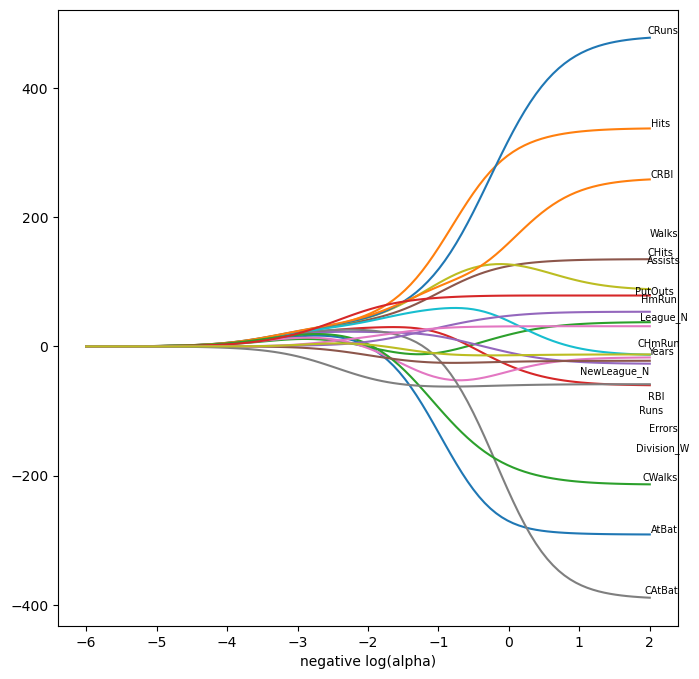

In [22]:
path_fig, ax = subplots(figsize=(8,8))

soln_path.plot(ax=ax, legend=False)

x_max = soln_path.index[-1]

texts = []

for col in soln_path.columns:
    y_end = soln_path[col].iloc[-1]
    texts.append(ax.text(x_max,y_end,col,fontsize=7))



adjust_text(texts,ax=ax, only_move={'text':'y'},force_text = (0.5,1.0));



In [23]:
beta_hat = soln_path.iloc[39]
alphas[39], np.linalg.norm(beta_hat)

(np.float64(705.4802310718638), np.float64(84.41074083895582))

In [24]:
beta_hat = soln_path.iloc[59]
alphas[59], np.linalg.norm(beta_hat)

(np.float64(17.073526474706888), np.float64(263.7108488877868))

In [25]:
ridge = skl.Ridge(alpha=0.01)
scaler = StandardScaler()
pipe = Pipeline(steps = [('scaler',scaler),('ridge',ridge)])

validation = skm.ShuffleSplit(n_splits = 1,
                test_size=0.5,
                random_state = 0)


results = skm.cross_validate(pipe,X,Y,scoring = 'neg_mean_squared_error',cv= validation)


-results['test_score']


array([133821.45286659])

In [26]:
param_grid = {'ridge__alpha':alphas}

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv = validation,
                        scoring = 'neg_mean_squared_error'
                        )


grid.fit(X,Y)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...alpha=0.01))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([1.0000...00000000e-02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",ShuffleSplit(...ain_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [27]:
grid.best_params_['ridge__alpha']

np.float64(0.8697490026177817)

In [31]:
K = 10
kfold = skm.KFold(K,random_state=0, shuffle=True)

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv = kfold,
                        scoring = 'neg_mean_squared_error'
                        )


grid.fit(X,Y)
grid.best_params_['ridge__alpha']

np.float64(3.199267137797378)

In [32]:
grid.cv_results_

{'mean_fit_time': array([0.00376337, 0.00219853, 0.00213971, 0.0019099 , 0.00170114,
        0.00154963, 0.00151794, 0.00154407, 0.0013669 , 0.00135572,
        0.00140262, 0.00143776, 0.00133591, 0.00194385, 0.0013495 ,
        0.00118644, 0.00128598, 0.00131512, 0.00128832, 0.00129094,
        0.00133069, 0.00139027, 0.00127213, 0.00132222, 0.00133851,
        0.001266  , 0.00118778, 0.00142999, 0.00131986, 0.00125399,
        0.00130358, 0.0012877 , 0.00124059, 0.00123718, 0.0012583 ,
        0.00134449, 0.00136225, 0.00125549, 0.00132999, 0.00127153,
        0.00136092, 0.00134645, 0.00134029, 0.00139515, 0.00141778,
        0.00142057, 0.00135298, 0.00137367, 0.00128946, 0.00123544,
        0.00141425, 0.00129941, 0.0012377 , 0.00127749, 0.00140715,
        0.00125427, 0.00120459, 0.0013377 , 0.00125558, 0.00127704,
        0.00122373, 0.00125291, 0.00129054, 0.00124967, 0.00131257,
        0.00143936, 0.00132632, 0.00132263, 0.0014468 , 0.00132952,
        0.00123975, 0.00144315,

<ErrorbarContainer object of 3 artists>

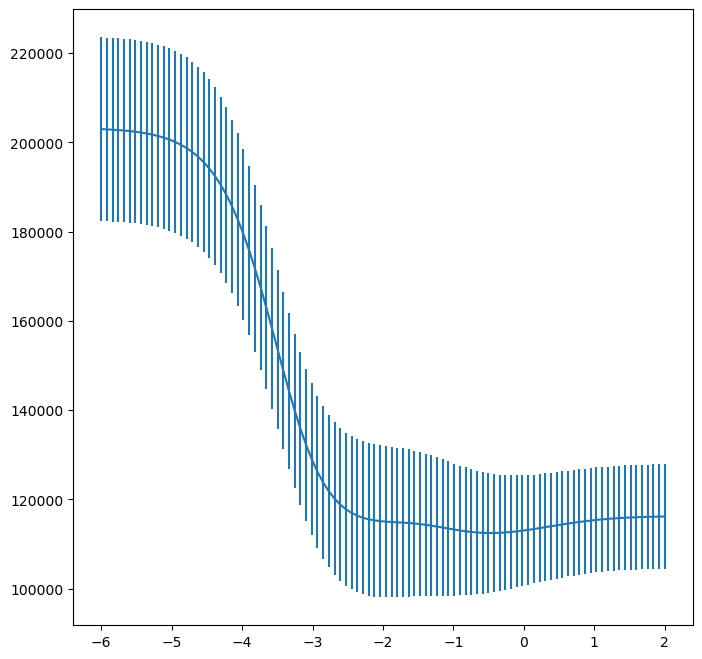

In [33]:
ridge_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log10(alphas),
            -grid.cv_results_['mean_test_score'],
            yerr = grid.cv_results_['std_test_score']/np.sqrt(K))

In [34]:
grid_r2 = skm.GridSearchCV(pipe,
                          param_grid,
                          cv = kfold)

grid_r2.fit(X,Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...alpha=0.01))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([1.0000...00000000e-02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

<ErrorbarContainer object of 3 artists>

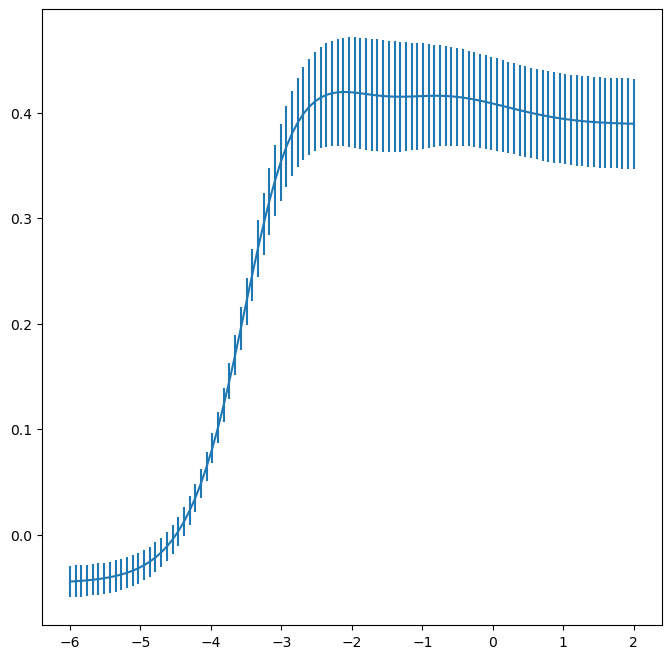

In [36]:
ridge_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log10(alphas),
            grid_r2.cv_results_['mean_test_score'],
            yerr = grid_r2.cv_results_['std_test_score']/np.sqrt(K))

In [ ]:
kfold = skm.KFold(10,random_state=1, shuffle=True)

ridgeCV = skl.RidgeCV(alphas = alphas,store_cv_results = True)

pipeCV = Pipeline(steps = [('scaler',StandardScaler()),('ridge',ridgeCV)])

pipeCV.fit(X,Y)

tuned_ridge = pipeCV.named_steps['ridge']
tuned_ridge.alpha_

3.199267137797378

In [67]:
ridgeLOO = skl.RidgeCV(alphas=alphas, store_cv_results=True)
pipeLOO = Pipeline(steps=[('scaler', StandardScaler()),
                          ('ridge', ridgeLOO)])
pipeLOO.fit(X, Y)
loo_mse = ridgeLOO.cv_results_.mean(0) # Average error for all the samples
loo_mse.min()

np.float64(114398.78166158483)

In [63]:
ridge_mse

array([535.92382462, 535.92340578, 535.92290214, 535.92229675,
       535.92156938, 535.92069586, 535.9196475 , 535.91839021,
       535.91688368, 535.91508043, 535.9129248 , 535.91035188,
       535.9072866 , 535.90364288, 535.89932316, 535.89421853,
       535.88820972, 535.88116947, 535.87296677, 535.86347378,
       535.852576  , 535.84018662, 535.82626541, 535.8108425 ,
       535.79404603, 535.77613192, 535.75751212, 535.73877571,
       535.72069623, 535.70421776, 535.69041434, 535.68042105,
       535.67534184, 535.67614626, 535.68357316, 535.69806082,
       535.71971923, 535.74835056, 535.78351276, 535.82461111,
       535.87099733, 535.92205631, 535.97726647, 536.03622742,
       536.09865732, 536.16436799, 536.23322874, 536.30512952,
       536.37995002, 536.45753778, 536.53769368, 536.62016187,
       536.70462156, 536.7906798 , 536.87786776, 536.96564403,
       537.0534091 , 537.14053288, 537.22639397, 537.31042536,
       537.39215805, 537.47125336, 537.5475159 , 537.62

In [71]:
#outer_valid = skm.ShuffleSplit(n_splits = 1, test_size = 0.2, random_state=1)

kfold = skm.KFold(20,random_state=1, shuffle=True)


ridgeCV = skl.RidgeCV(alphas = alphas)

pipeCV = Pipeline(steps = [('scaler',StandardScaler()),('ridge',ridgeCV)])

results = skm.cross_validate(pipeCV,X,Y,cv = kfold,scoring = 'neg_mean_squared_error')

-results['test_score'].mean()


np.float64(119236.61990563793)

In [72]:
Hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [74]:
Y

array([ 475.   ,  480.   ,  500.   ,   91.5  ,  750.   ,   70.   ,
        100.   ,   75.   , 1100.   ,  517.143,  512.5  ,  550.   ,
        700.   ,  240.   ,  775.   ,  175.   ,  135.   ,  100.   ,
        115.   ,  600.   ,  776.667,  765.   ,  708.333,  750.   ,
        625.   ,  900.   ,  110.   ,  612.5  ,  300.   ,  850.   ,
         90.   ,   67.5  ,  180.   ,  305.   ,  215.   ,  247.5  ,
        815.   ,  875.   ,   70.   , 1200.   ,  675.   ,  415.   ,
        340.   ,  416.667, 1350.   ,   90.   ,  275.   ,  230.   ,
        225.   ,  950.   ,   75.   ,  105.   ,  320.   ,  850.   ,
        535.   ,  933.333,  850.   ,  210.   ,  325.   ,  275.   ,
        450.   , 1975.   , 1900.   ,  600.   , 1041.667,  110.   ,
        260.   ,  475.   ,  431.5  , 1220.   ,   70.   ,  145.   ,
        595.   , 1861.46 ,  300.   ,  490.   , 2460.   ,  375.   ,
        750.   , 1175.   ,   70.   , 1500.   ,  385.   , 1925.571,
        215.   ,  900.   ,  155.   ,  700.   ,  535.   ,  362.

In [98]:

kfold = skm.KFold(100,random_state=1, shuffle=True)

lassoCV = skl.LassoCV(n_alphas = 100,cv=kfold)

pipeCV = Pipeline(steps = ([('scaler',StandardScaler()),
                            ('lasso',lassoCV)]))

pipeCV.fit(X,Y)

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",100
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [99]:
pipeCV.named_steps['lasso'].alpha_

np.float64(2.3807693760172444)

In [87]:
alphas_lasso = np.logspace(4,-2,100)

coefs_lasso = []

for alpha in alphas_lasso:
    lasso = skl.Lasso(alpha=alpha,max_iter = 10000)
    pipe = Pipeline(steps=[('scaler',StandardScaler()),('lasso',lasso)])
    pipe.fit(X,Y)
    coefs_lasso.append(pipe.named_steps['lasso'].coef_)


soln_path_lasso = pd.DataFrame(coefs_lasso,
                               columns = feature_names,
                               index = -np.log10(alphas_lasso))

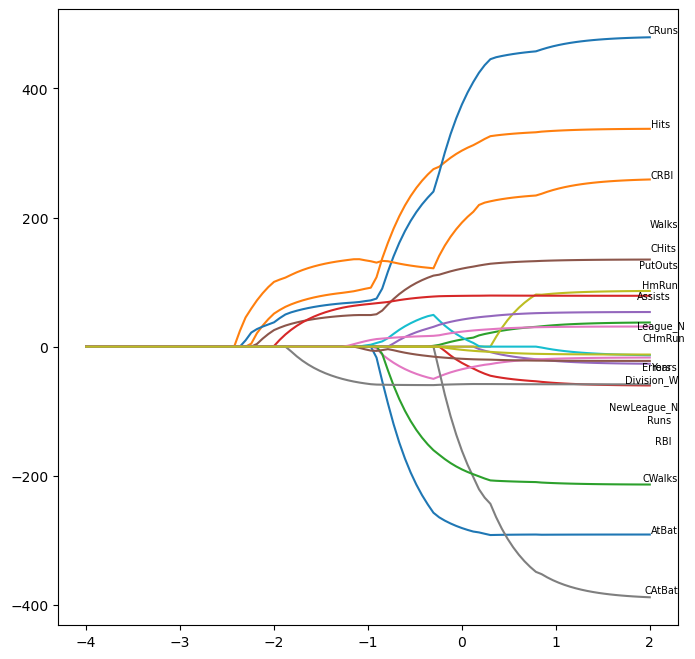

In [88]:
path_fig, ax = subplots(figsize=(8,8))

soln_path_lasso.plot(ax=ax, legend=False)

x_max = soln_path_lasso.index[-1]

texts = []

for col in soln_path.columns:
    y_end = soln_path_lasso[col].iloc[-1]
    texts.append(ax.text(x_max,y_end,col,fontsize=7))



adjust_text(texts,ax=ax, only_move={'text':'y'},force_text = (0.5,1.0));

In [100]:
np.min(pipeCV.named_steps['lasso'].mse_path_.mean())

np.float64(123762.80400321903)

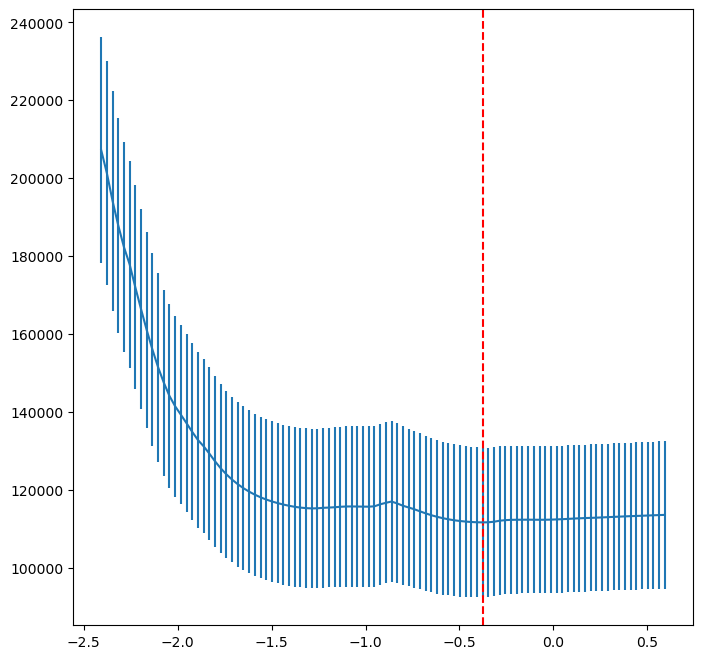

In [102]:
lasso_fig, ax = subplots(figsize=(8,8))

tuned_lasso = pipeCV.named_steps['lasso']



ax.errorbar(-np.log10(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr = tuned_lasso.mse_path_.std(1)/np.sqrt(100))

ax.axvline(-np.log10(tuned_lasso.alpha_),c='red',ls='--')